# Data Generation

In questo notebook andiamo a generare i dati campionati tramite sensori circa la temperatura superficiale dell'artefatto.
Tali dati permetteranno di definire le condizioni al contorno del modello che analizzeremo tramite Physics-Informed Neural Networks.
Tra le assunzioni necessarie all'esperimento richiederemo che:

*   La temperatura sia uniforme intorno all'artefatto e che si modifichi con continuità nel tempo

*   L'artefatto è composto da un unico materiale e la variazione di temperatura interna sia un fenomeno continuo

L'obiettivo è di definire un problema ben posto secondo Hadamard (la soluzione esiste, è unica, e dipende con continuità dai dati).

Inizialmente effettuiamo gli imput necessari e fissiamo il seme del generatore per garantire la riproducibilità.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output

In [2]:
seed = 10
np.random.seed(seed)

## Fase uno: generazione dei dati di temperatura visti come una gaussiana all'interno della giornata

Supponiamo di effettuare $1000$ misurazioni tramite un sensore nel corso della giornata (l'intervallo considerato sarà $\left[0, 1 \right]$). I tempi di campionatura sono equispaziati

In [3]:
number_samples = 100
mean_temperature = 22.4
std_temperature = 1.2

temperature = np.random.normal(
    loc=mean_temperature,
    scale=std_temperature,
    size=(number_samples)
)

Eliminiamo gli outliers e sostituiamoli con una stima

In [4]:
over_std_idx = np.logical_and(abs(temperature - mean_temperature) - 2*std_temperature >= 0, temperature - mean_temperature >= 0)
under_std_idx = np.logical_and(abs(temperature - mean_temperature) - 2*std_temperature >= 0, temperature - mean_temperature <= 0)
temperature[over_std_idx] = mean_temperature + 2*std_temperature
temperature[under_std_idx] = mean_temperature - 2*std_temperature

Suddividiamo i campioni secondo un andamento a campana

In [5]:
half = int(number_samples/2)

first_part = temperature[:half]
first_part.sort()
second_part = temperature[half:]
second_part.sort()
second_part = np.flip(second_part)

temperature = np.concatenate([first_part, second_part])

Inseriamo i dati in un dataframe

In [6]:
date_range = pd.date_range(start='2024-01-01 00:00:00', end='2024-01-01 23:59:00', periods=number_samples)
temperature_data = pd.DataFrame({'Datetime': date_range, 'Temperature_C': temperature})

Grafichiamo la temperatura campionata

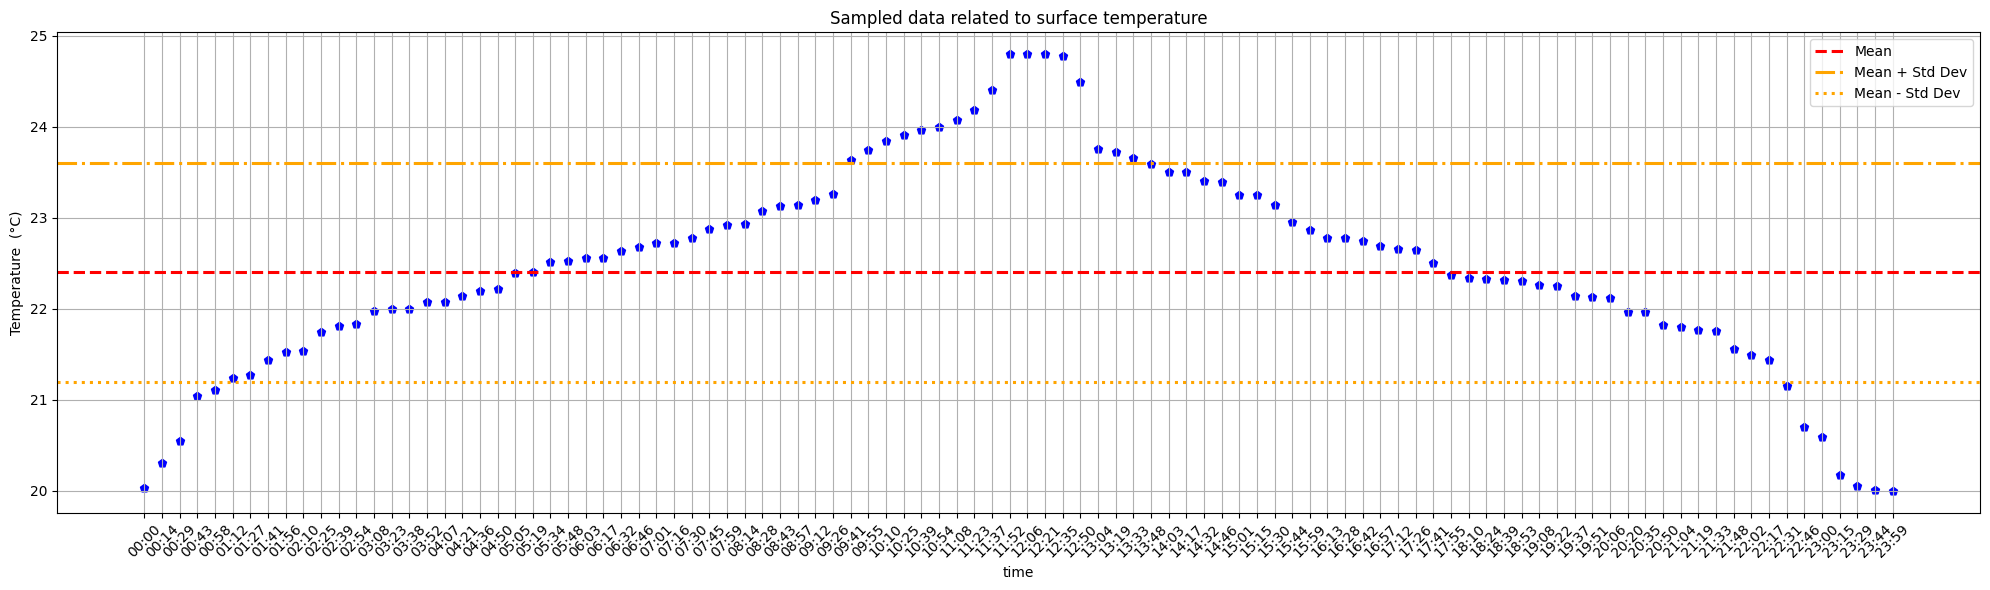

In [7]:
mean_plus_std = mean_temperature + std_temperature
mean_minus_std = mean_temperature - std_temperature

plt.figure(figsize=(20, 6))
plt.scatter(temperature_data['Datetime'], temperature_data['Temperature_C'], color='blue', marker="p")
plt.axhline(mean_temperature, color='red', linestyle='--', label='Mean', linewidth=2.2)
plt.axhline(mean_plus_std, color='orange', linestyle='-.', label='Mean + Std Dev', linewidth=2.2)
plt.axhline(mean_minus_std, color='orange', linestyle=':', label='Mean - Std Dev', linewidth=2.2)
plt.legend()
plt.title("Sampled data related to surface temperature")
plt.xlabel("time")
plt.ylabel("Temperature  (°C)")
plt.grid(True)
plt.xticks(temperature_data['Datetime'], temperature_data['Datetime'].dt.strftime('%H:%M'), rotation=45)
plt.tight_layout()
plt.show()

## Fase due: salvataggio dei campioni

In [8]:
temperature_data.to_csv("TempData.csv", sep=";", index=False)

## Fase tre: minimi quadrati su base non polinomiale per approssimare i dati

Definiamo la base non polinomiale
$$
  \left\{ 1, \sin{x}, \cos{x} \right\}
  \tag{1}
$$
per l'applicazione di minimi quadrati. L'obiettivo è di individuare la funzione che meglio approssima i dati simulati lungo la giornata. In particolare, considereremo gli istanti temporali nell'intervallo $\left[0, 1 \right]$, dove l'unità rappresenta l'intera giornata.

In [9]:
# Individuazione dei punti temporali in [0, 1]
starting_point, ending_point = 0, 1
time = np.linspace(starting_point, ending_point, number_samples).reshape((number_samples, 1))

A = np.concatenate(
    [
        np.ones((number_samples, 1)),
        np.sin(time),
        np.cos(time),
    ],
    axis=-1
)
y = temperature_data['Temperature_C'].values.reshape((number_samples, 1))

c = np.linalg.solve(A.T @ A, A.T @ y)

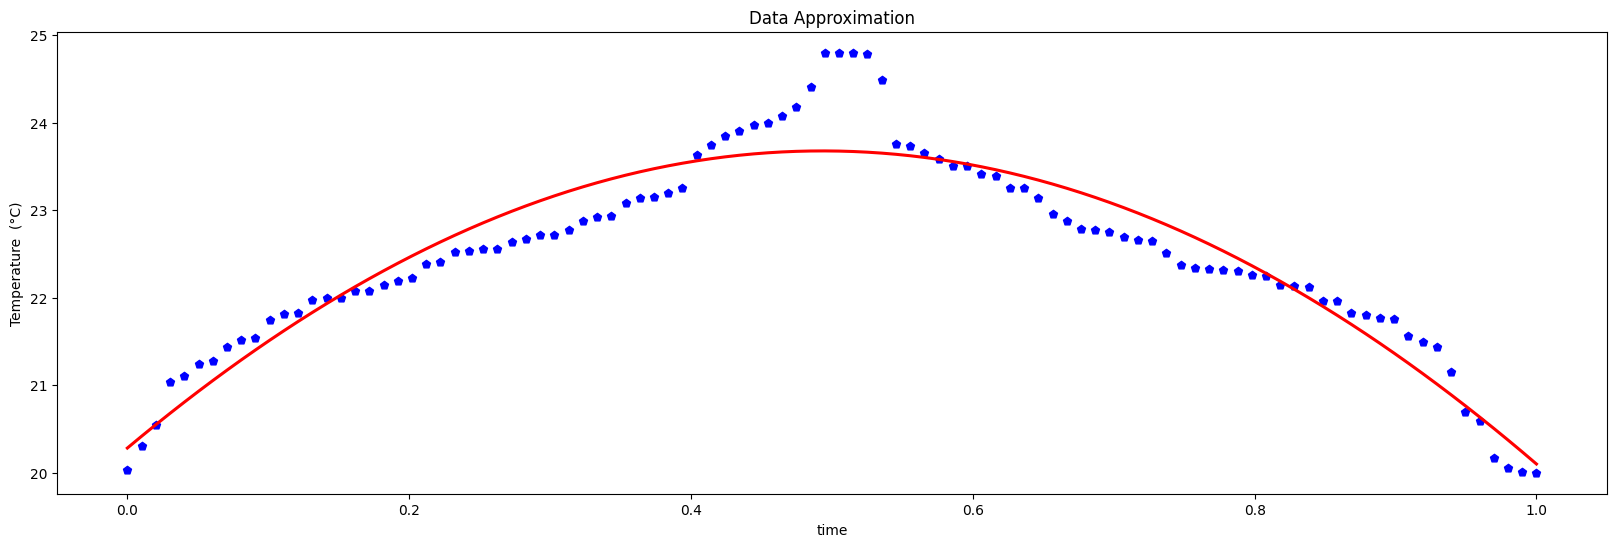

In [10]:
out_ls = np.zeros(time.shape)
out_ls = (
    c[0,0] + c[1, 0]*np.sin(time) + c[2, 0]*np.cos(time)
)

plt.figure(figsize=(20, 6))
plt.scatter(time, temperature_data['Temperature_C'], color='blue', marker="p")
plt.plot(time, out_ls, "-", linewidth=2.2, color="red")
plt.title("Data Approximation")
plt.xlabel("time")
plt.ylabel("Temperature  (°C)")
plt.show()

## Fase quattro: rete neurale per approssimare i dati

Definiamo i dati

In [11]:
import torch
from torchsummary import summary

torch.set_default_dtype(torch.float32)

X = torch.tensor(time, dtype=torch.float32)
Y = torch.tensor(temperature_data["Temperature_C"].values.reshape(number_samples, 1), dtype=torch.float32)

Impostiamo la rete

In [12]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, input_dim, output_dim, mean_temp):
        super(NeuralNetwork, self).__init__()
        self.mean = mean_temp
        self.layers = torch.nn.Sequential(
            torch.nn.Linear(
                in_features=input_dim,
                out_features=10
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                in_features=10,
                out_features=10
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                in_features=10,
                out_features=10
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                in_features=10,
                out_features=output_dim
            )
        )


    def forward(self, x):
        return self.mean + self.layers(x)

# Creazione di un'istanza della rete neurale
model = NeuralNetwork(X.shape[1], Y.shape[1], mean_temperature)

# Ottenimento di un sommario della rete neurale
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]              20
              Tanh-2                   [-1, 10]               0
            Linear-3                   [-1, 10]             110
              Tanh-4                   [-1, 10]               0
            Linear-5                   [-1, 10]             110
              Tanh-6                   [-1, 10]               0
            Linear-7                    [-1, 1]              11
Total params: 251
Trainable params: 251
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


Addestramento della rete

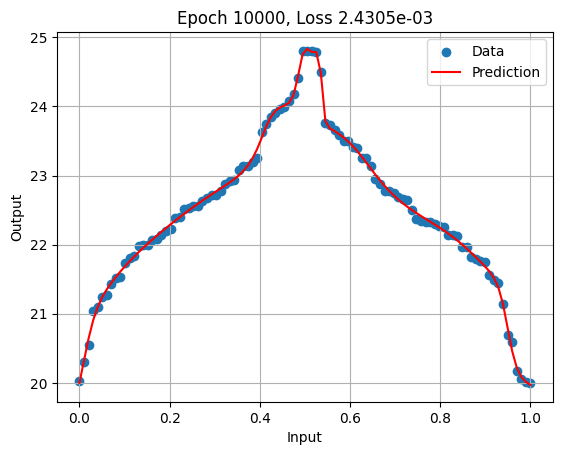

In [13]:
# Definizione della funzione di loss (ad esempio, MSE per regressione)
criterion = torch.nn.MSELoss()

# Definizione dell'ottimizzatore Adam e impostazione del learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Numero di epoche di training
num_epochs = 10000

loss_history = list()

# Ciclo di training
for epoch in range(num_epochs):
    # Azzeramento del gradiente
    optimizer.zero_grad()
    # Forward pass
    outputs = model(X)
    # Calcolo della loss
    loss = criterion(outputs, Y)
    # Backward pass
    loss.backward()
    # Ottimizzazione dei pesi
    optimizer.step()
    # Stampa della loss durante il training
    if ((epoch+1) % 200) == 0:
        #print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))
        # Pulizia dell'output
        clear_output(wait=True)
        # Tracciamento delle previsioni
        plt.clf()
        plt.scatter(X.detach().numpy(), Y.detach().numpy(), label='Data')
        plt.plot(X.detach().numpy(), outputs.detach().numpy(), color='red', label='Prediction')
        plt.xlabel('Input')
        plt.ylabel('Output')
        plt.title(f'Epoch {epoch+1}, Loss {loss.item():.4e}')
        plt.legend()
        plt.grid(True)
        plt.show()
    loss_history.append(loss.item())


Stampa della loss

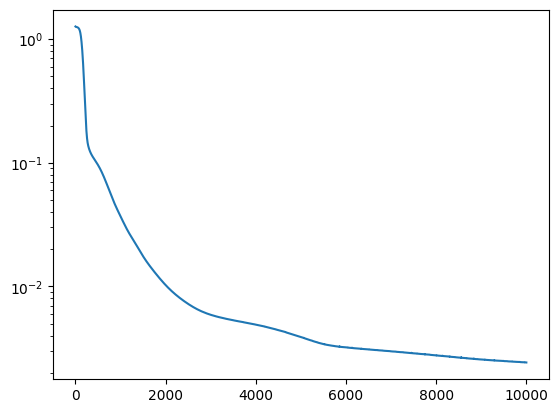

In [14]:
plt.plot(np.arange(num_epochs)+1, loss_history)
plt.yscale("log")
plt.show()

Stampa dell'approssimazione

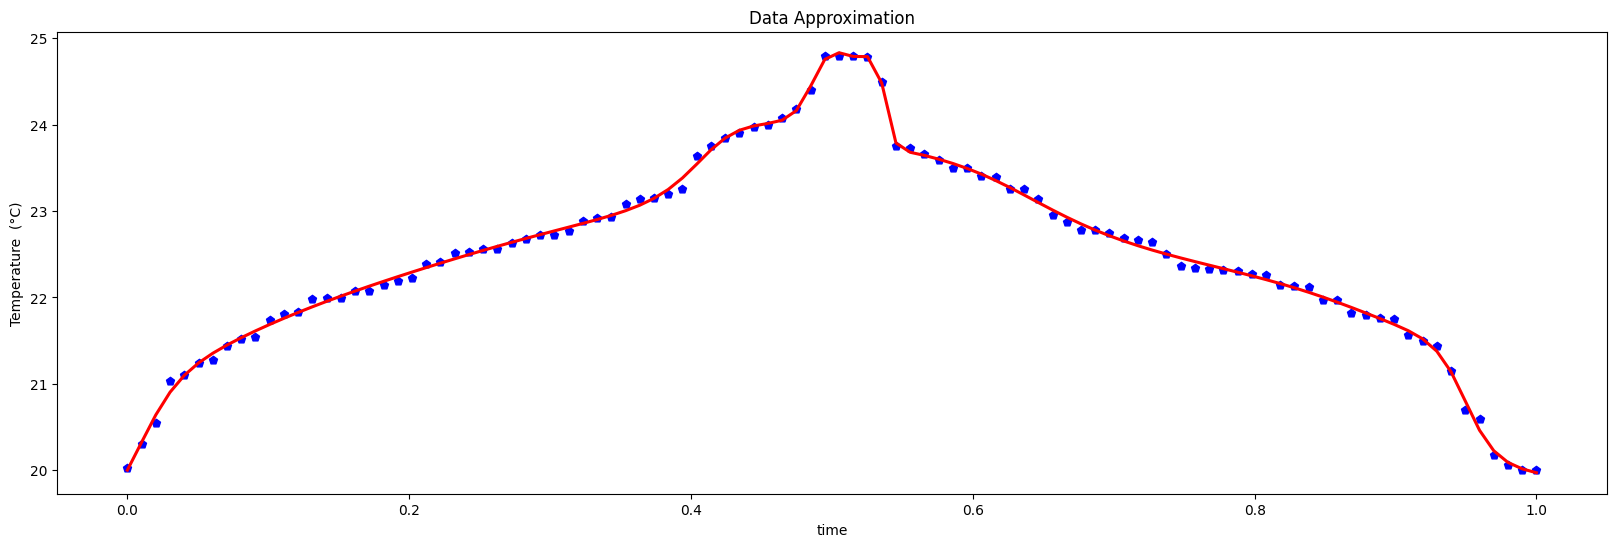

In [15]:
out_nn = model(torch.tensor(time, dtype=torch.float32)).detach().numpy()

plt.figure(figsize=(20, 6))
plt.scatter(time, temperature_data['Temperature_C'], color='blue', marker="p")
plt.plot(time, out_nn, "-", linewidth=2.2, color="red")
plt.title("Data Approximation")
plt.xlabel("time")
plt.ylabel("Temperature  (°C)")
plt.show()

Salvataggio del modello addestrato

In [16]:
# Percorso di salvataggio del modello
path = "boundary.pth"

# Salvataggio dell'intero modello
torch.save(model, path)

Esempio di caricamento del modello

In [17]:
# Percorso del file in cui è stato salvato il modello
path = "boundary.pth"

# Caricamento del modello
loaded_model = torch.load(path)

# Assicurati che il modello sia in modalità di valutazione
loaded_model.eval()

# Input corretto
input_tensor = torch.tensor([[0.5]], dtype=torch.float32)

# Esegui la predizione con il modello caricato
output = loaded_model(input_tensor)

# Stampa dell'output
print(output)

tensor([[24.8233]], grad_fn=<AddBackward0>)


## Confronto tra i metodi

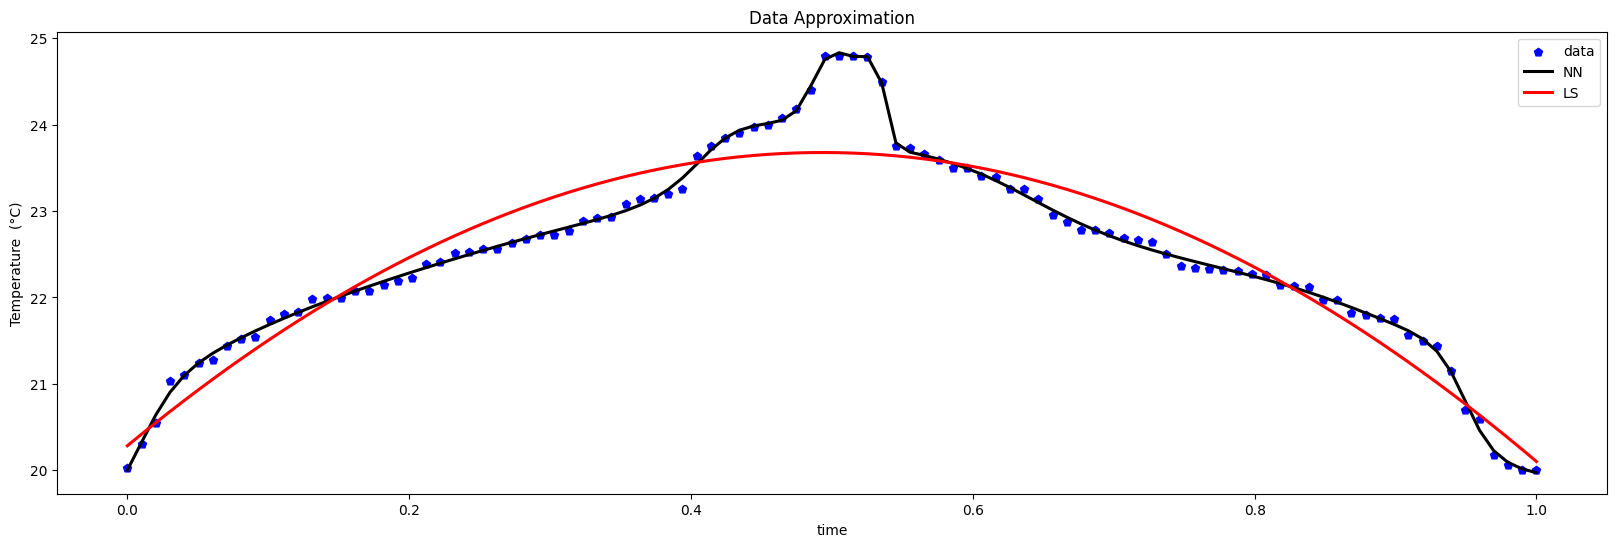

In [18]:
plt.figure(figsize=(20, 6))
plt.scatter(time, temperature_data['Temperature_C'], color='blue', marker="p", label="data")
plt.plot(time, out_nn, "-", linewidth=2.2, color="black", label="NN")
plt.plot(time, out_ls, "-", linewidth=2.2, color="red", label="LS")
plt.legend()
plt.title("Data Approximation")
plt.xlabel("time")
plt.ylabel("Temperature  (°C)")
plt.show()